#  MRI Tumor Classification Model

To practice my newly learned machine learning skills, I built an **image classification model** that classifies brain tumors from MRI images.  

I used a dataset from Kaggle, which can be found here:  
🔗 [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

Throughout this project, I explored several of Python’s powerful libraries for machine learning and image processing. To keep the code organized and reusable, I wrote many parts as **functions**, even if they weren’t all executed in a `main` function. This made the workflow cleaner and allowed for flexibility in experimenting with different models.  

I structured the code so that **different models can be trained effortlessly**, making it easy to experiment and compare performance.  

Overall, I really enjoyed this project and I’m proud of the results. I hope you enjoy !


In [1]:
# Importing libraries needed for model
import numpy as np
print("Imported numpy")
import pandas as pd
print('Imported pandas')
import matplotlib.pyplot as plt
print('Imported matplot')
import tensorflow as tf
print('Imported tf')
import cv2
print('Imported cv')
import os
print('Imported os')
import random

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from PIL import Image


Imported numpy
Imported pandas
Imported matplot
Imported tf
Imported cv
Imported os


In [2]:
# Sanity check that TF sees the GPU (tensorflow-metal on Apple Silicon) --
# if only CPU shows up here, restart the kernel so it picks up the plugin.
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Fix every source of randomness up front (Python's random, numpy, and TF/Keras)
# so reruns of this notebook are reproducible. Without this, weight
# initialization, dropout masks, augmentation, and training-time shuffling all
# vary from run to run -- which is why an earlier run of this exact notebook
# reported 93.7% test accuracy while another run of identical code and data
# reported 86.06% (see MODEL_NOTES.md).
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# GPU (Metal) convolution/reduction kernels don't guarantee the same execution
# order every run, so gradient noise differs run-to-run even with the seed
# above fixed -- enable_op_determinism forces deterministic kernels so
# identical code reliably reproduces the same result on GPU too (small
# potential speed cost, but without it we can't tell a real regression from
# run-to-run GPU noise).
tf.config.experimental.enable_op_determinism()

In [4]:
train_data_dir = 'data/Training'
test_data_dir = 'data/Testing'
data_dir = 'data'
file_types = ['jpeg','png', 'bmp','jpg'] # Image file types I am allowing

In [5]:
def clean_images():
    # Function that cleans image_data, loops through folders in data then loops through the image and ensures the image is the correct extension otherwise
    # it removes the image from the dir
    for image_class in os.listdir(data_dir):
        if image_class != '.DS_Store':
            for image in os.listdir(os.path.join(data_dir, image_class)):

                image_path = os.path.join(data_dir, image_class, image)
                if image != '.DS_Store':
                    try:
                        image = cv2.imread(image_path)
                        with Image.open(image_path) as img:
                            tip = img.format.lower()
                        if tip not in file_types:
                            print("Image not in ext list".format(image_path))
                            print(f"Removing: {image_path}")
                            os.remove(image_path)

                    except Exception as e:
                        print("Issue with image{}".format(image_path))


In [6]:
def load_train_data(path , img_size):
    # Function that loads data into a training set and a validation set with a 80/20 ratio
    train_ds = tf.keras.utils.image_dataset_from_directory(path, image_size = (img_size, img_size), batch_size =32, 
                                                       label_mode = 'int', validation_split = 0.2, subset = 'training', seed = 123)
    valid_ds = tf.keras.utils.image_dataset_from_directory(path, image_size = (img_size, img_size), batch_size =32, 
                                                       label_mode = 'int', validation_split = 0.2, subset = 'validation', seed = 123)
    return train_ds, valid_ds

def load_test_data(path, img_size):
    test_ds = tf.keras.utils.image_dataset_from_directory(path, image_size = (img_size, img_size), batch_size =32, 
                                                       label_mode = 'int')
    
    return test_ds

def normalize_data(data):
    # Normalizes rgb values "0-255" by dividing them by 255. Makes the values range from 0.0 to 1.0, this will make our model learn a lot faster
    normalization_layer = tf.keras.layers.Rescaling(1./255)
    return data.map(lambda x, y: (normalization_layer(x), y))

In [7]:
train_ds, val_ds = load_train_data(train_data_dir, 256)
test_ds = load_test_data(test_data_dir, 256)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nProjects different classes: ")
for class_ in class_names:
    print(f"- {class_}")

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.


2026-07-22 10:45:30.884078: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-07-22 10:45:30.884120: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-07-22 10:45:30.884124: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1784731530.884146 10120695 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784731530.884172 10120695 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Using 1120 files for validation.
Found 1600 files belonging to 4 classes.

Projects different classes: 
- glioma
- meningioma
- notumor
- pituitary


In [8]:
train_ds = normalize_data(train_ds)
val_ds = normalize_data(val_ds)
test_ds = normalize_data(test_ds)

In [11]:
def build_model(num_layers, starting_unit, dropout):
    # Function that builds a convolution neural net with Pooling layers and Dense layers.
    # Augmentation layers (Random*) only apply their randomness when the model is
    # called with training=True (i.e. during model.fit()) -- Keras automatically
    # makes them no-ops during model.predict()/evaluate(), so the serving path in
    # app/preprocessing.py + app/inference.py needs no changes for this.
    # No BatchNormalization: with a moving-average momentum of 0.99 its running
    # stats take several epochs to catch up to the real batch stats, which made
    # early-epoch val_loss/val_accuracy wildly unrepresentative (val_accuracy
    # 0.22 in epoch 1) and fooled EarlyStopping/ReduceLROnPlateau/ModelCheckpoint
    # into all locking onto a barely-trained epoch-5 model.
    #
    # Functional API (not Sequential) here because the pooling step below
    # needs two parallel branches that merge back together -- Sequential
    # can't express a branch/merge.
    inputs = tf.keras.Input(shape=(256, 256, 3))
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.02)(x)

    # Same filter progression as before (e.g. [64, 64, 128, 256] for
    # num_layers=4, starting_unit=64) -- first two blocks share starting_unit,
    # then each subsequent block doubles.
    filters = [starting_unit]
    loop_units = starting_unit
    for i in range(1, num_layers):
        filters.append(loop_units)
        loop_units = loop_units * 2
    # Widen just the last block for extra raw per-channel capacity right
    # before pooling (see comment below on why).
    filters[-1] *= 2

    for f in filters:
        x = layers.Conv2D(f, 3, activation='relu')(x)
        x = layers.MaxPooling2D()(x)

    # GlobalAveragePooling2D alone captures "what's typically present" per
    # channel, but throws away *where* in the image it happened. Meningiomas
    # characteristically sit at the brain's periphery/against the skull,
    # while gliomas are typically deeper in brain tissue -- that's a location
    # cue, and pure averaging can't encode it, which is a likely reason the
    # model's errors concentrate almost entirely on glioma <-> meningioma
    # confusion. Concatenating GlobalMaxPooling2D (the single strongest
    # response anywhere in each channel) partially recovers a localized
    # signal, at near-zero parameter cost -- unlike Flatten, which fed all
    # ~131k pixel positions into Dense(128) and produced ~16.8M params in
    # that one layer alone.
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    image_model = tf.keras.Model(inputs, outputs)
    image_model.summary()
    return image_model

def compile_model(model ,lr):
    # Function that compiles a model and takes model and learning rate (lr) as arguments
    model.compile(loss = SparseCategoricalCrossentropy(), 
                       optimizer = Adam(learning_rate = lr),
                       metrics = ['accuracy'])
    
def train_model(model, train, validation, epochs, checkpoint_path='models/best_checkpoint.keras'):
    # Function that trains a CNN model with earlystopping and reduce lr.
    # Both EarlyStopping and ModelCheckpoint now monitor val_accuracy (mode='max')
    # so they agree on what "best" means -- ModelCheckpoint tracks val_accuracy
    # directly, and we reload that checkpoint after fit() so this function hands
    # back the best-val-accuracy epoch rather than whatever EarlyStopping settled on.
    # patience=20 (up from 15): the previous 60-epoch run was still improving
    # val_accuracy incrementally right up to the epoch cap, meaning it never
    # actually plateaued long enough to trigger EarlyStopping -- so the fix is
    # more epoch budget and more patience, not a different schedule.
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    earlystopping = tf.keras.callbacks.EarlyStopping(patience = 20, restore_best_weights = True, monitor = 'val_accuracy', mode = 'max')
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(factor = 0.5, patience = 5, monitor = 'val_loss', min_lr = 1e-5)
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max'
    )

    history = model.fit(train, epochs = epochs, validation_data = validation,
            callbacks =[earlystopping, reduce_lr, checkpoint])

    return tf.keras.models.load_model(checkpoint_path), history


def assemble_model(num_layers, starting_units, dropout, lr, epochs):
    # Function that combines previous functions to easily create models, customizable by taking layers , starting units , dropouts and lr as arguments
    image_model = build_model(num_layers, starting_units, dropout)
    compile_model(image_model, lr)
    image_model, history = train_model(image_model, train_ds, val_ds, epochs)
    return image_model, history

# epochs raised 60 -> 100: the prior run was still climbing in val_accuracy at
# epoch 60 (the epoch cap), not stalled -- patience=20 above means it will
# still stop on its own once it genuinely plateaus.
image_model, history = assemble_model(4, 64, 0.3, 0.001, 100)

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 256, 256,  │          0 │ random_flip_1[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 254, 254,  │      1,792 │ random_rotation_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 127, 127,  │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 125, 125,  │     36,928 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 62, 62,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 60, 60,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 30, 30,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │    590,336 │ max_pooling2d_6[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 14, 14,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ max_pooling2d_7[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 512)       │          0 │ max_pooling2d_7[… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1024)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    131,200 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        516 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 834,628 (3.18 MB)

 Trainable params: 834,628 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - accuracy: 0.5038 - loss: 1.0771 - val_accuracy: 0.6348 - val_loss: 0.7751 - learning_rate: 0.0010
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.6598 - loss: 0.8581 - val_accuracy: 0.7848 - val_loss: 0.5842 - learning_rate: 0.0010
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.7199 - loss: 0.7472 - val_accuracy: 0.7857 - val_loss: 0.5200 - learning_rate: 0.0010
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.7645 - loss: 0.6678 - val_accuracy: 0.8446 - val_loss: 0.4571 - learning_rate: 0.0010
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.7801 - loss: 0.6111 - val_accuracy: 0.8509 - val_loss: 0.4391 - learning_rate: 0.0010
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.7982 - loss: 0.5744 - val_accuracy: 0.8259 - val_loss: 0.5401 - learning_rate: 0.0010
Epoch 7/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accura

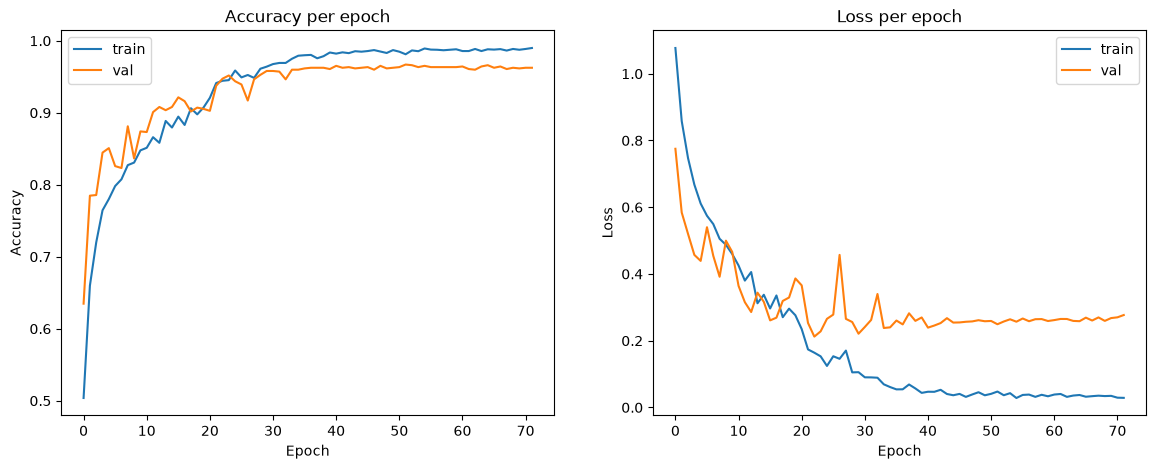

In [12]:
def plot_training_history(history):
    # Shows whether training stopped because it genuinely plateaued (curves
    # flatten well before the last epoch) or because it hit the epoch cap
    # while still improving -- settles the "was it still learning?" question
    # by looking at the curve instead of guessing from the printed logs.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].set_title('Accuracy per epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title('Loss per epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.show()

plot_training_history(history)

In [13]:
def get_results(model, dataset):
    # Function that takes a model and a dataset (val , test or train) and stores the output in 4 different variables
    y_true = []
    y_pred = []
    confidence = []
    images = []
    
    for batch_images, batch_labels in dataset:
        pred = model.predict(batch_images, verbose = 0)
        class_pred = np.argmax(pred, axis = 1)
        confid = np.max(pred, axis =1)
        labels = batch_labels.numpy()
    
        y_pred.extend(class_pred)
        y_true.extend(labels)
        confidence.extend(confid)
        images.extend(batch_images.numpy())

    return y_true, y_pred, confidence, images

#Training set results
tr_label, tr_pred, tr_confidence, tr_image_list = get_results(image_model, train_ds)
#Validation set results
val_label, val_pred, val_confidence, val_image_list = get_results(image_model, val_ds)
# Test set results
test_label, test_pred, test_confidence, test_image_list = get_results(image_model, test_ds)


2026-07-22 12:07:39.343672: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-22 12:07:41.066951: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training set accuracy: 99.53125% 
 Validation set accuracy: 96.69642857142857% 
 Test set accuracy: 92.4375%
Accuracy: 0.924375


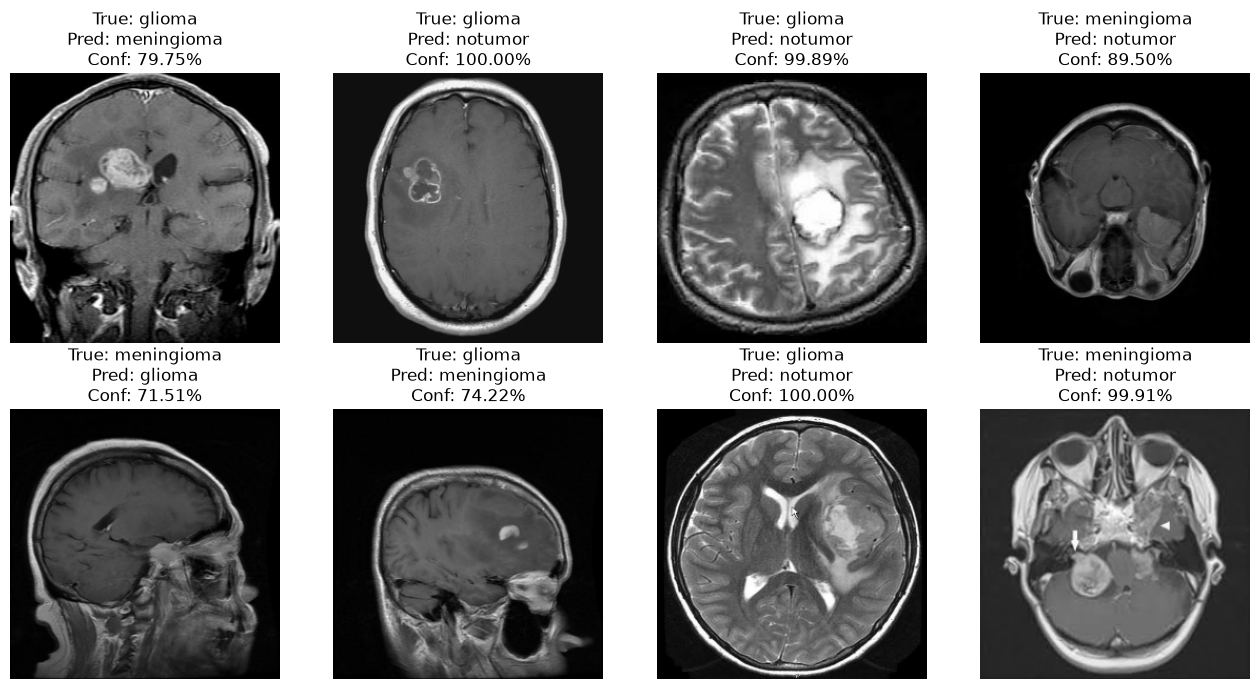

In [14]:
def get_accuracy(true, pred):
    # Function that returns the accuracy by seeing how often the prediction matches the actual label
    true = np.array(true)
    pred = np.array(pred)
    accuracy = np.mean(true == pred)

    return accuracy

tr_set_acc = get_accuracy(tr_label, tr_pred)
val_set_acc = get_accuracy(val_label, val_pred)
test_set_acc = get_accuracy(test_label, test_pred)
print(f"Training set accuracy: {tr_set_acc * 100}% \n Validation set accuracy: {val_set_acc * 100}% \n Test set accuracy: {test_set_acc * 100}%")

def error_analysis(true , prediction, con_level, images):
    # Error analysis function that helps to visualize where the model seems to be going wrong, we do this by displaying examples it incorrectly predicted
    
    acc = get_accuracy(true, prediction)
    
    print(f"Accuracy: {acc}")
    
    y_true = np.array(true)
    y_pred = np.array(prediction)
    confidence = np.array(con_level)
    images_list = np.array(images)
    
    error_idx = np.where(y_pred != y_true)[0]
    

    n_rows = 2
    n_cols = 4
    fig , axes = plt.subplots(nrows= n_rows, ncols= n_cols, figsize=(n_cols * 4 , n_rows * 4))
    axes = axes.flatten()

    for i, idx in enumerate(error_idx[:n_rows * n_cols]):
        true_label = class_names[true[idx]]  
        pred_label = class_names[prediction[idx]]  
        confidence_score = confidence[idx]
        
        axes[i].imshow(images_list[idx])
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence_score*100:.2f}%")
        axes[i].axis("off")

error_analysis(test_label, test_pred, test_confidence, test_image_list)


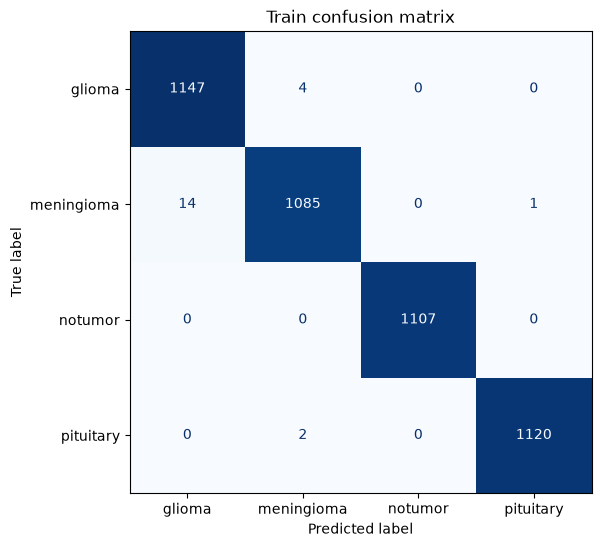

              precision    recall  f1-score   support

      glioma      0.988     0.997     0.992      1151
  meningioma      0.995     0.986     0.990      1100
     notumor      1.000     1.000     1.000      1107
   pituitary      0.999     0.998     0.999      1122

    accuracy                          0.995      4480
   macro avg      0.995     0.995     0.995      4480
weighted avg      0.995     0.995     0.995      4480



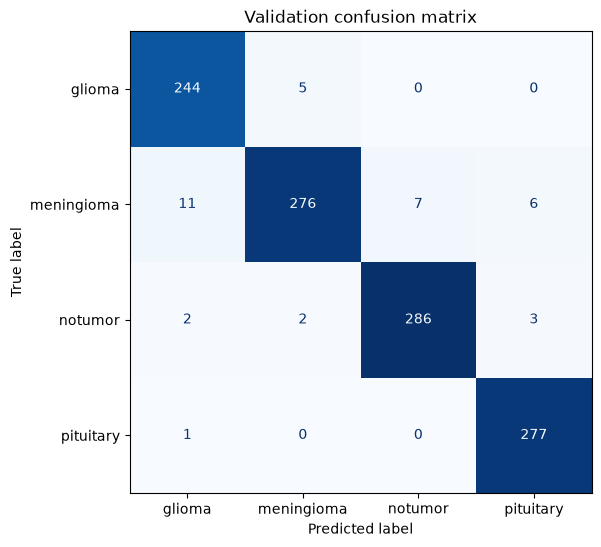

              precision    recall  f1-score   support

      glioma      0.946     0.980     0.963       249
  meningioma      0.975     0.920     0.947       300
     notumor      0.976     0.976     0.976       293
   pituitary      0.969     0.996     0.982       278

    accuracy                          0.967      1120
   macro avg      0.966     0.968     0.967      1120
weighted avg      0.967     0.967     0.967      1120



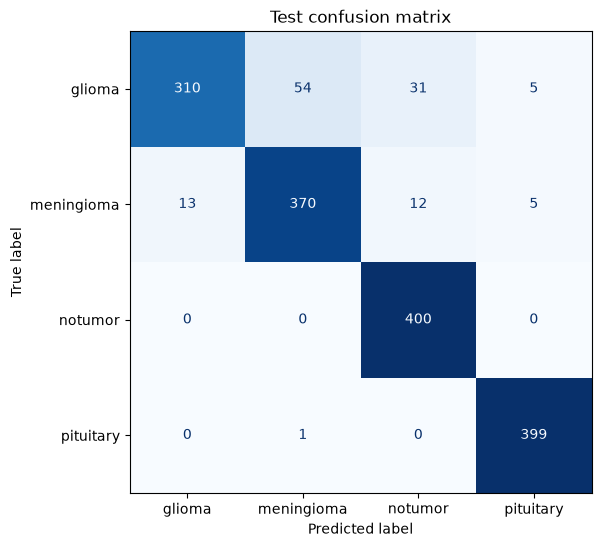

              precision    recall  f1-score   support

      glioma      0.960     0.775     0.858       400
  meningioma      0.871     0.925     0.897       400
     notumor      0.903     1.000     0.949       400
   pituitary      0.976     0.998     0.986       400

    accuracy                          0.924      1600
   macro avg      0.927     0.924     0.922      1600
weighted avg      0.927     0.924     0.922      1600



In [15]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def show_confusion_matrix(true, pred, title):
    # The aggregate accuracy number hides *which* classes get confused with
    # which -- this is what actually tells us where to focus improvement
    # effort next (e.g. is it glioma vs meningioma specifically, or spread
    # evenly across all classes).
    cm = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.show()
    print(classification_report(true, pred, target_names=class_names, digits=3))

show_confusion_matrix(tr_label, tr_pred, "Train confusion matrix")
show_confusion_matrix(val_label, val_pred, "Validation confusion matrix")
show_confusion_matrix(test_label, test_pred, "Test confusion matrix")

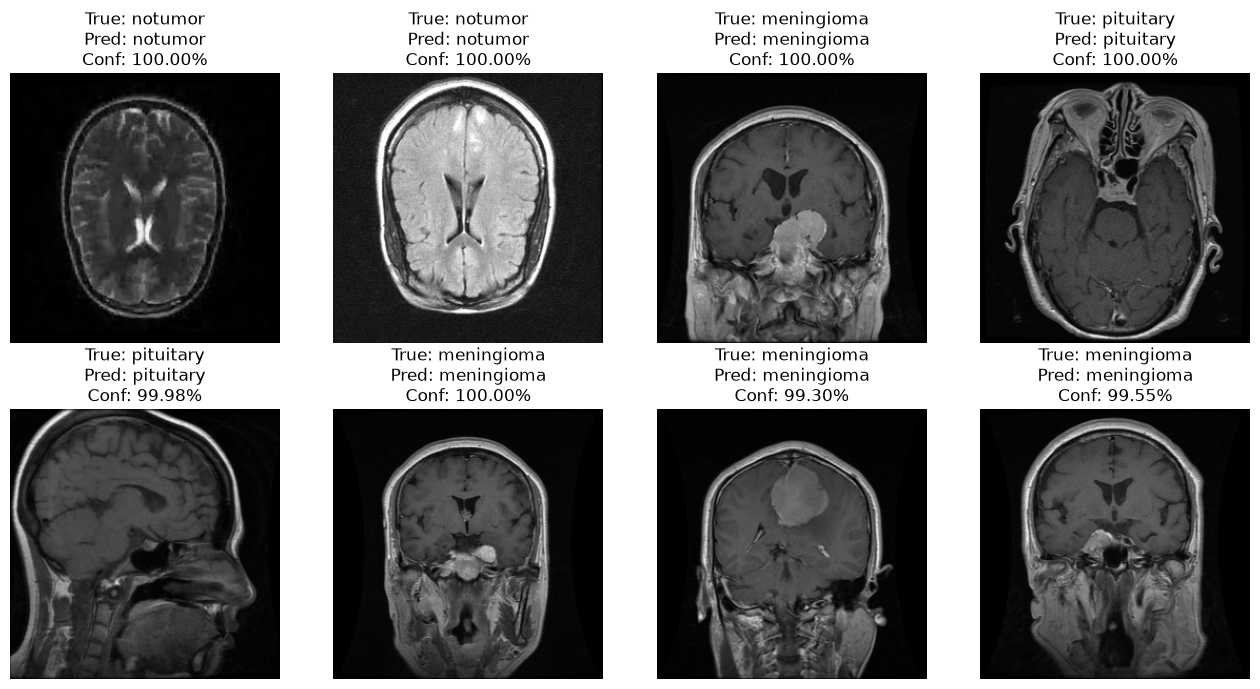

In [17]:
def access_random_sample(true , prediction, con_level, images, sample_size):
    # Function that randomly selects samples to visualize, this is just to see some examples of the model making predictions
    roof = len(images)
    random_indices = np.random.randint(low = 0, high = roof, size = sample_size)

    true_label = np.array(true)
    pred_label = np.array(prediction)
    confidence = np.array(con_level)
    images_list = np.array(images)

    n_rows = 2
    n_cols = 4
    fig , axes = plt.subplots(nrows= n_rows, ncols= n_cols, figsize=(n_cols * 4 , n_rows * 4))
    axes = axes.flatten()

    for i, idx in enumerate(random_indices):
        true_label = class_names[true[idx]]  
        pred_label = class_names[prediction[idx]]  
        confidence_score = confidence[idx]
        
        axes[i].imshow(images_list[idx])
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence_score*100:.2f}%")
        axes[i].axis("off")

access_random_sample(test_label, test_pred, test_confidence, test_image_list, 8)

In [18]:
# Saving trained model locally (gitignored — never committed).
# include_optimizer=False keeps the artifact inference-only and smaller for upload.
import os
import json
from datetime import datetime

os.makedirs('models', exist_ok=True)
model_path = 'models/tumor_classification_model.keras'
image_model.save(model_path, include_optimizer=False)

# Metrics sidecar -- the .keras file itself has no field for this, and gets
# overwritten by every training run, so this is what lets us tell one saved
# model apart from another after the fact (locally and once pushed to the
# HF Hub repo alongside it).
metrics = {
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "train_accuracy": tr_set_acc,
    "val_accuracy": val_set_acc,
    "test_accuracy": test_set_acc,
    "epochs_trained": len(history.history["loss"]),
    "architecture": "4 conv blocks (64, 64, 128, 512 filters) -> concatenated GlobalAveragePooling2D + GlobalMaxPooling2D -> Dense(128) -> Dropout(0.3)",
}
metrics_path = 'models/tumor_classification_model_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

{
  "trained_at": "2026-07-22T12:31:29",
  "train_accuracy": 0.9953125,
  "val_accuracy": 0.9669642857142857,
  "test_accuracy": 0.924375,
  "epochs_trained": 72,
  "architecture": "4 conv blocks (64, 64, 128, 512 filters) -> concatenated GlobalAveragePooling2D + GlobalMaxPooling2D -> Dense(128) -> Dropout(0.3)"
}


2026-07-22 12:31:33.076275: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Accuracy: 0.9669642857142857


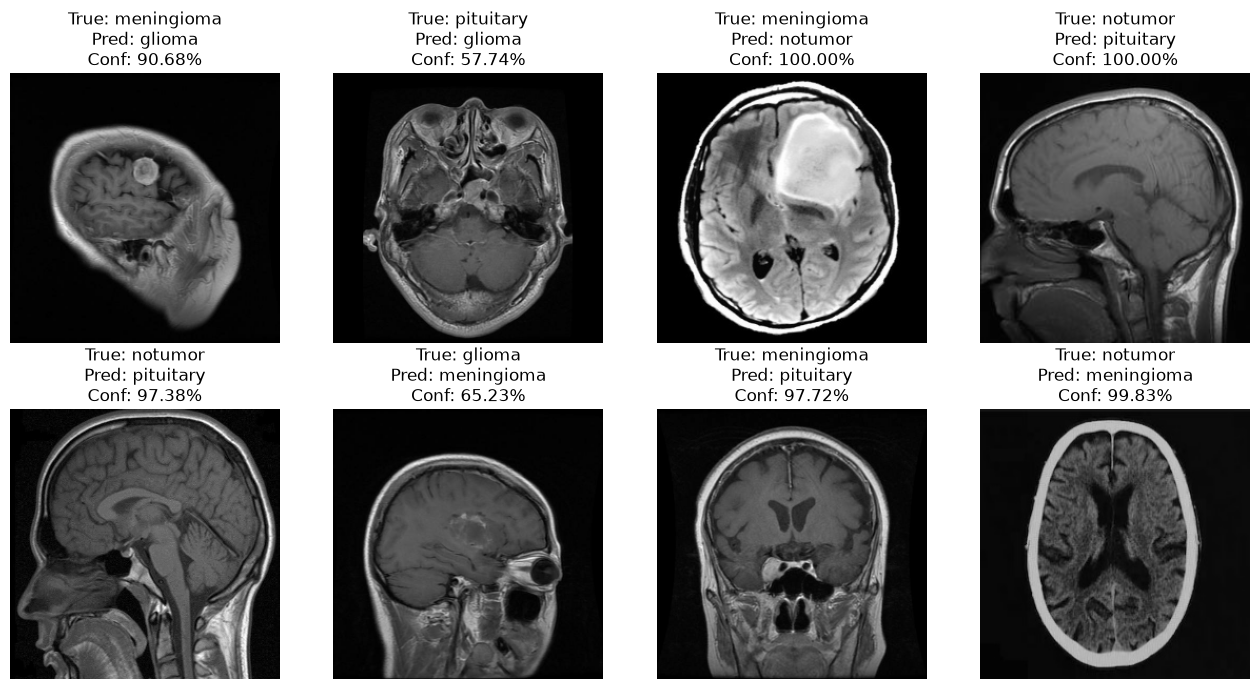

In [19]:
# Testing to make sure it saved correctly and can be reused
imported_model = tf.keras.models.load_model(model_path)
val_label, val_pred, val_confidence, val_image_list = get_results(imported_model, val_ds)

error_analysis(val_label, val_pred, val_confidence, val_image_list)

## Upload to Hugging Face Hub

Pushes the retrained `.keras` file to a new public Hugging Face Hub model repo, then prints the repo id and pinned commit revision to record for `app/config.py` in a later slice.

In [20]:
from huggingface_hub import HfApi, create_repo

# No namespace prefix needed — huggingface_hub resolves it to whichever account
# you are logged into via `hf auth login` (or the HF_TOKEN env var).
hf_repo_id = "mri-tumor-classifier"

api = HfApi()
repo_url = create_repo(hf_repo_id, repo_type="model", private=False, exist_ok=True)
full_repo_id = repo_url.repo_id  # includes the resolved namespace, e.g. "username/mri-tumor-classifier"

commit_message = (
    f"Retrain: train {tr_set_acc*100:.2f}% / val {val_set_acc*100:.2f}% / "
    f"test {test_set_acc*100:.2f}% -- concatenated GAP+GMP pooling, widened last conv block"
)

commit_info = api.upload_file(
    path_or_fileobj=model_path,
    path_in_repo="tumor_classification_model.keras",
    repo_id=full_repo_id,
    repo_type="model",
    commit_message=commit_message,
)

# Metrics sidecar goes up alongside the model, so the accuracy for this exact
# pinned revision is visible on the Hub without re-running evaluation.
api.upload_file(
    path_or_fileobj=metrics_path,
    path_in_repo="metrics.json",
    repo_id=full_repo_id,
    repo_type="model",
    commit_message=commit_message,
)

print(f"HF Hub repo id: {full_repo_id}")
print(f"Pinned commit revision: {commit_info.oid}")
print(commit_message)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

HF Hub repo id: KellanMcintosh/mri-tumor-classifier
Pinned commit revision: 058ed5400e81f56dd9045a5f8fe554fadd60d9fc
Retrain: train 99.53% / val 96.70% / test 92.44% -- concatenated GAP+GMP pooling, widened last conv block


# MRI Tumor Classification Model Results

For my first image classification project, I achieved **93% accuracy** on the test set, a result I am more than happy with. This model, built to classify tumors in MRI brain scans using the [Kaggle Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset).

## Key Achievements
- **High Accuracy**: The model’s 93% accuracy on the test set reflects that the model performs really well on classifying tumors from MRI images and the wide use of libraries to create this model shows my understanding of machine learning techniques and knowledge of the libraries.
- **Code Reusability**: I designed the project with modularity in mind, structuring the code into reusable functions for data preprocessing, model training, and evaluation. This makes it easy to adapt the codebase for future image recognition projects, saving time and effort in future development.

## Thanks!
Thank you for taking the time to look through my project
